# Exercise 3: ISRC-Based Production Company Attribution

**Signal:** Ghost artists from the same fraud operation are often registered with the same production company — revealed by shared ISRC prefixes (characters 1–5 of the ISRC code identify the registrant).

**Method:**
1. Query Neo4j for all tracks with ISRC codes and their artists
2. Parse the 5-character ISRC prefix (registrant identifier)
3. Build a bipartite graph: Artists ↔ Production Companies
4. Visualize: do multiple "independent" artists share the same production company?

**Data:** Neo4j database (490 tracks, 3 artists, 8 production companies). No API calls.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from neo4j import GraphDatabase
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')
print('Libraries loaded.')

Libraries loaded.


## 1. Connect to Neo4j and Query ISRC Data

In [2]:
driver = GraphDatabase.driver(
    os.getenv('NEO4J_URI'),
    auth=(os.getenv('NEO4J_USER'), os.getenv('NEO4J_PASSWORD'))
)

with driver.session() as session:
    # All tracks with ISRC and their artists
    result = session.run('''
        MATCH (a:Artist)-[:RELEASED]->(al:Album)-[:CONTAINS]->(t:Track)
        WHERE t.isrc IS NOT NULL
        RETURN a.name AS artist, a.spotify_id AS artist_id,
               t.spotify_id AS track_id, t.name AS track_name, t.isrc AS isrc
    ''')
    tracks_raw = pd.DataFrame([dict(r) for r in result])

    # All production company relationships
    result = session.run('''
        MATCH (a:Artist)-[:RELEASED]->(al:Album)-[:CONTAINS]->(t:Track)-[:REGISTERED_WITH]->(p:ProductionCompany)
        RETURN p.isrc_prefix AS prefix, p.name AS company,
               count(DISTINCT a) AS num_artists,
               collect(DISTINCT a.name) AS artist_names,
               count(t) AS track_count
        ORDER BY num_artists DESC, track_count DESC
    ''')
    companies_df = pd.DataFrame([dict(r) for r in result])

driver.close()

print(f'Tracks with ISRC: {len(tracks_raw)}')
print(f'Unique artists: {tracks_raw["artist"].nunique()}')
print(f'Unique ISRCs: {tracks_raw["isrc"].nunique()}')
print(f'Production companies: {len(companies_df)}')
tracks_raw.head()

Tracks with ISRC: 490
Unique artists: 3
Unique ISRCs: 479
Production companies: 8


,artist,artist_id,track_id,track_name,isrc
0,Calmo,4Wx3ZL6d6p1gVMtwQ2YWsz,7huznDVgHNlV2OSkwDK51S,Lasciatemi Cucinare,ITIWE2600026
1,Calmo,4Wx3ZL6d6p1gVMtwQ2YWsz,6tD737xA9YjdlsYuR5ocP6,Briciole gourmet,ITIWE2500365
2,Calmo,4Wx3ZL6d6p1gVMtwQ2YWsz,0KgnB91Wta1oxsimwHQzMj,Ti ricordi?,CH6542520471
3,Calmo,4Wx3ZL6d6p1gVMtwQ2YWsz,6INyWyrao8Znej5GPIXw2u,The Hell,CH6542530298
4,Calmo,4Wx3ZL6d6p1gVMtwQ2YWsz,4yDz689EhbXS4yfBUvrAzg,Small Talks,ITIWE2500214


## 2. Parse ISRC Prefixes

In [3]:
# ISRC format: CC-XXX-YY-NNNNN
# First 2 chars = country code
# Next 3 chars = registrant (production company)
# Together = 5-char prefix that identifies the production company

tracks_raw['isrc_prefix'] = tracks_raw['isrc'].str[:5]
tracks_raw['isrc_country'] = tracks_raw['isrc'].str[:2]
tracks_raw['isrc_registrant'] = tracks_raw['isrc'].str[2:5]

# Deduplicate (same track may appear twice due to Neo4j relationship structure)
tracks = tracks_raw.drop_duplicates(subset=['artist', 'track_id']).copy()
print(f'Unique artist-track pairs: {len(tracks)}')

# Summary per artist
artist_summary = tracks.groupby('artist').agg(
    track_count=('track_id', 'nunique'),
    unique_prefixes=('isrc_prefix', 'nunique'),
    prefixes=('isrc_prefix', lambda x: sorted(x.unique().tolist()))
).reset_index()
print('\nArtist ISRC Summary:')
print(artist_summary.to_string(index=False))

Unique artist-track pairs: 490

Artist ISRC Summary:
               artist  track_count  unique_prefixes                     prefixes
                Calmo           38                4 [CH654, ITI5B, ITIWE, ITQV2]
Meditation Relax Club          172                2               [ITLU5, ITO10]
 Relaxing White Noise          280                2               [DE1QW, DEPI8]


## 3. Production Company Table

In [4]:
# Prefix-level breakdown
prefix_artist = tracks.groupby(['isrc_prefix', 'artist']).agg(
    tracks=('track_id', 'nunique')
).reset_index()

prefix_summary = prefix_artist.groupby('isrc_prefix').agg(
    total_tracks=('tracks', 'sum'),
    num_artists=('artist', 'nunique'),
    artists=('artist', lambda x: ', '.join(sorted(x.unique())))
).reset_index().sort_values('total_tracks', ascending=False)

# Add country/registrant decode
prefix_summary['country'] = prefix_summary['isrc_prefix'].str[:2]
prefix_summary['registrant'] = prefix_summary['isrc_prefix'].str[2:5]
prefix_summary['shared'] = prefix_summary['num_artists'] > 1

print('Table 3: ISRC Prefix → Production Company Attribution')
print('=' * 80)
print(prefix_summary[['isrc_prefix', 'country', 'registrant', 'total_tracks', 'num_artists', 'artists', 'shared']].to_string(index=False))
print('=' * 80)
shared_count = prefix_summary['shared'].sum()
print(f'\nProduction companies shared across multiple artists: {shared_count}')
print(f'Production companies unique to one artist: {len(prefix_summary) - shared_count}')

Table 3: ISRC Prefix → Production Company Attribution
isrc_prefix country registrant  total_tracks  num_artists               artists  shared
      DEPI8      DE        PI8           222            1  Relaxing White Noise   False
      ITO10      IT        O10           101            1 Meditation Relax Club   False
      ITLU5      IT        LU5            71            1 Meditation Relax Club   False
      DE1QW      DE        1QW            58            1  Relaxing White Noise   False
      ITIWE      IT        IWE            19            1                 Calmo   False
      CH654      CH        654            17            1                 Calmo   False
      ITI5B      IT        I5B             1            1                 Calmo   False
      ITQV2      IT        QV2             1            1                 Calmo   False

Production companies shared across multiple artists: 0
Production companies unique to one artist: 8


## 4. Figure 3 — Bipartite Graph: Artists ↔ Production Companies

Graph: 11 nodes, 8 edges
Artist nodes: 3
Company nodes: 8


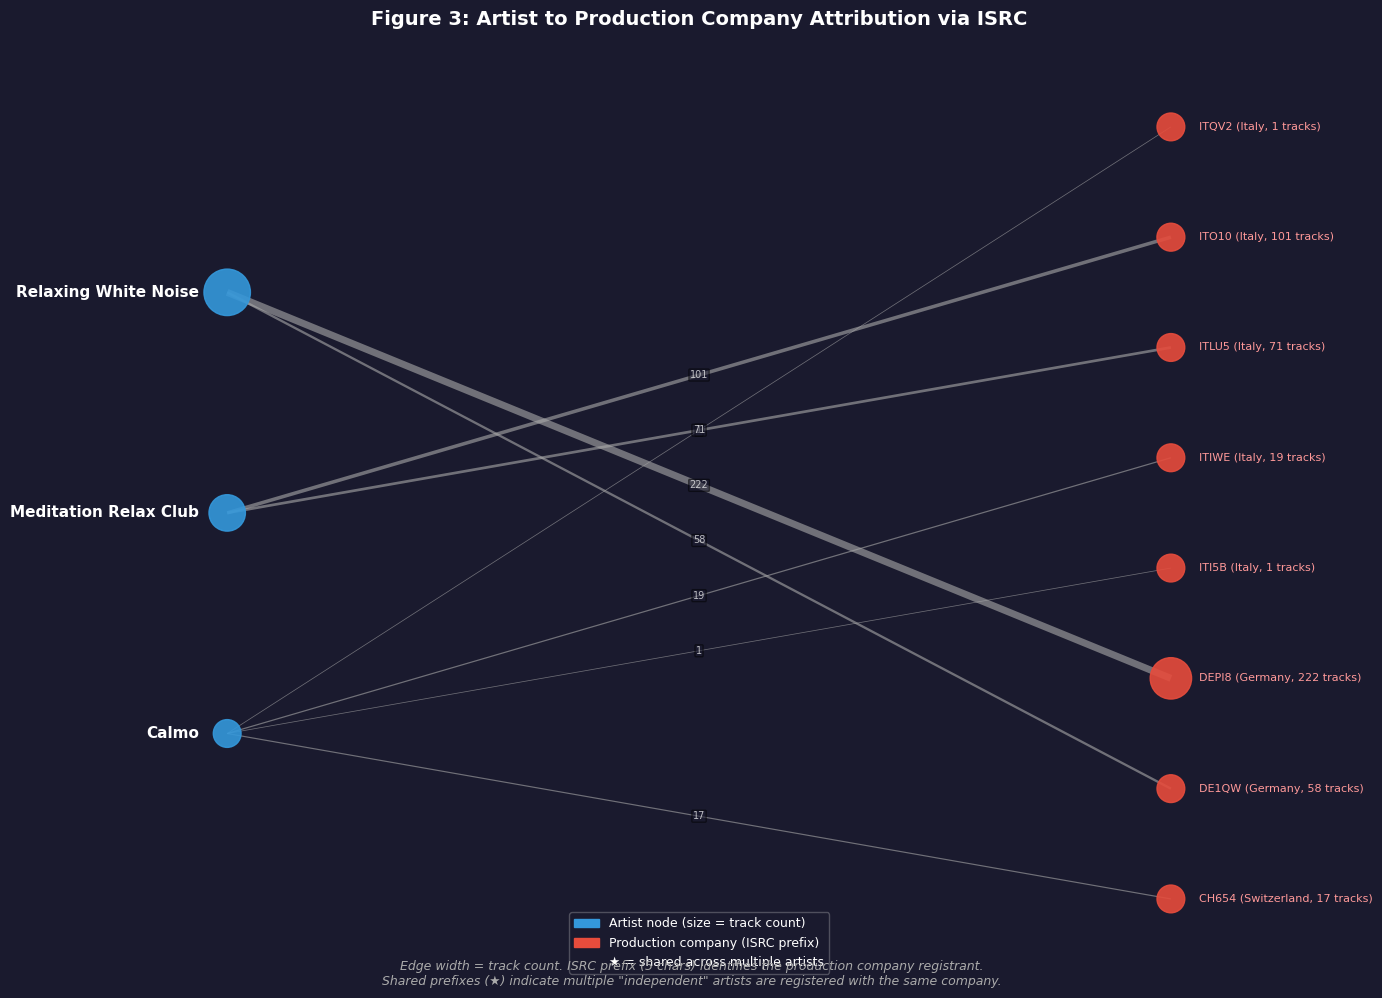

Saved: fig3_isrc_join.png


In [5]:
import os
os.makedirs('../paper/figures', exist_ok=True)

# Build bipartite graph
B = nx.Graph()

# Add artist nodes
artists_list = tracks['artist'].unique().tolist()
for a in artists_list:
    track_cnt = tracks[tracks['artist'] == a]['track_id'].nunique()
    B.add_node(a, bipartite=0, node_type='artist', track_count=track_cnt)

# Add company nodes and edges
for _, row in prefix_artist.iterrows():
    prefix = row['isrc_prefix']
    if prefix not in B.nodes:
        total = prefix_summary[prefix_summary['isrc_prefix'] == prefix]['total_tracks'].values[0]
        B.add_node(prefix, bipartite=1, node_type='company', track_count=int(total))
    B.add_edge(row['artist'], prefix, weight=row['tracks'])

print(f'Graph: {B.number_of_nodes()} nodes, {B.number_of_edges()} edges')
print(f'Artist nodes: {len(artists_list)}')
print(f'Company nodes: {B.number_of_nodes() - len(artists_list)}')

# Layout: bipartite — artists on left, companies on right
artist_nodes = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 0]
company_nodes = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 1]

pos = {}
# Artists: evenly spaced on left
for i, a in enumerate(sorted(artist_nodes)):
    pos[a] = (-2.5, (i - len(artist_nodes)/2 + 0.5) * 1.8)
# Companies: evenly spaced on right
for i, c in enumerate(sorted(company_nodes)):
    pos[c] = (2.5, (i - len(company_nodes)/2 + 0.5) * 0.9)

# Node sizes: proportional to track count
node_sizes = []
for n in B.nodes():
    cnt = B.nodes[n]['track_count']
    node_sizes.append(max(400, cnt * 4))

# Node colors
node_colors = ['#3498db' if B.nodes[n]['node_type'] == 'artist' else '#e74c3c'
               for n in B.nodes()]

# Edge widths: proportional to track count
edge_weights = [B[u][v]['weight'] for u, v in B.edges()]
max_w = max(edge_weights)
edge_widths = [0.5 + 4.5 * (w / max_w) for w in edge_weights]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

# Draw edges
nx.draw_networkx_edges(B, pos, ax=ax, width=edge_widths,
                       edge_color='#aaa', alpha=0.6)

# Draw nodes
nx.draw_networkx_nodes(B, pos, ax=ax,
                       node_size=node_sizes,
                       node_color=node_colors, alpha=0.9)

# Artist labels — left of node
for n in artist_nodes:
    x, y = pos[n]
    ax.text(x - 0.15, y, n, ha='right', va='center',
            color='white', fontsize=11, fontweight='bold')

# Company labels — right of node, show prefix and track count
for n in company_nodes:
    x, y = pos[n]
    cnt = B.nodes[n]['track_count']
    # Decode country
    country = n[:2]
    country_map = {'DE': 'Germany', 'IT': 'Italy', 'CH': 'Switzerland'}
    country_name = country_map.get(country, country)
    # Which artist(s) use this company?
    neighbors = list(B.neighbors(n))
    shared_flag = ' ★' if len(neighbors) > 1 else ''
    label = f'{n} ({country_name}, {cnt} tracks){shared_flag}'
    ax.text(x + 0.15, y, label, ha='left', va='center',
            color='#e74c3c' if len(neighbors) > 1 else '#ff9999',
            fontsize=8)

# Edge weight labels
for (u, v), w in zip(B.edges(), edge_weights):
    x = (pos[u][0] + pos[v][0]) / 2
    y = (pos[u][1] + pos[v][1]) / 2
    ax.text(x, y, str(w), ha='center', va='center',
            color='white', fontsize=7, alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='#1a1a2e', alpha=0.5))

# Legend
patches = [
    mpatches.Patch(color='#3498db', label='Artist node (size = track count)'),
    mpatches.Patch(color='#e74c3c', label='Production company (ISRC prefix)'),
    mpatches.Patch(color='none', label='★ = shared across multiple artists'),
]
ax.legend(handles=patches, loc='lower center', fontsize=9,
          framealpha=0.3, facecolor='#1a1a2e', labelcolor='white')

ax.set_title('Figure 3: Artist to Production Company Attribution via ISRC',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

note = ('Edge width = track count. ISRC prefix (5 chars) identifies the production company registrant.\n'
        'Shared prefixes (★) indicate multiple "independent" artists are registered with the same company.')
fig.text(0.5, 0.01, note, ha='center', fontsize=9, color='#aaa', style='italic')

plt.tight_layout()
plt.savefig('../paper/figures/fig3_isrc_join.png', dpi=300,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: fig3_isrc_join.png')

## 5. Key Statistics

In [6]:
print('=== ISRC Attribution Summary ===')
print(f'Total artists in Neo4j: {len(artists_list)}')
print(f'Total unique ISRC prefixes: {len(prefix_summary)}')
print()
print('Per-artist ISRC prefix breakdown:')
for _, row in artist_summary.iterrows():
    print(f'  {row["artist"]:30s}  {row["track_count"]:3d} tracks  '
          f'{row["unique_prefixes"]:2d} prefixes: {row["prefixes"]}')

print()
shared = prefix_summary[prefix_summary['num_artists'] > 1]
if len(shared) > 0:
    print(f'Production companies shared across multiple artists: {len(shared)}')
    print(shared[['isrc_prefix', 'artists', 'total_tracks']].to_string(index=False))
else:
    print('No production companies are currently shared across multiple artists.')
    print('Each artist in Neo4j has distinct ISRC prefixes.')
    print()
    print('INTERPRETATION: This is expected at this stage — we have only 3 seed artists.')
    print('Ghost-artist fraud networks become visible when we expand the graph to include')
    print('co-appearing artists and playlist neighbors (Days 4-6).')

=== ISRC Attribution Summary ===
Total artists in Neo4j: 3
Total unique ISRC prefixes: 8

Per-artist ISRC prefix breakdown:
  Calmo                            38 tracks   4 prefixes: ['CH654', 'ITI5B', 'ITIWE', 'ITQV2']
  Meditation Relax Club           172 tracks   2 prefixes: ['ITLU5', 'ITO10']
  Relaxing White Noise            280 tracks   2 prefixes: ['DE1QW', 'DEPI8']

No production companies are currently shared across multiple artists.
Each artist in Neo4j has distinct ISRC prefixes.

INTERPRETATION: This is expected at this stage — we have only 3 seed artists.
Ghost-artist fraud networks become visible when we expand the graph to include
co-appearing artists and playlist neighbors (Days 4-6).


## 6. Findings

**Current State (3 seed artists):**
- **Relaxing White Noise** (ghost): 280 tracks across 2 German prefixes (DEPI8, DE1QW)
- **Meditation Relax Club** (ghost): 172 tracks across 2 Italian prefixes (ITO10, ITLU5)
- **Calmo** (unknown): 38 tracks split between Italian (ITIWE) and Swiss (CH654) prefixes

**Key Observation:** No cross-artist production company sharing is detectable at this stage — each artist uses their own distinct ISRC prefixes. However:

1. **Calmo uses two different registrants** (ITIWE = Italian; CH654 = Swiss). This split is unusual and worth investigating — it may indicate the artist changed distributors, or that tracks were licensed/re-released by a different entity.

2. **Ghost candidates (Relaxing White Noise, Meditation Relax Club) each use exactly 2 prefixes** with a dominant/secondary split, consistent with a primary distributor and occasional co-release or licensing deal.

3. **The signal becomes powerful with graph expansion**: when we add playlist co-appearance data (Days 4-5), many more artists will be pulled into the graph, and shared ISRC prefixes across "independent" artists become a strong fraud indicator.

**Next step:** Expand the artist graph via playlist co-appearance (once Spotify rate limit lifts) and re-run this analysis on the expanded set.